# Low pass filtering

As specified on the datasheet and register map, the MPU6050 has a built-in digital low pass filter. It's helpful because it provides some smoothing, noise reduction and anti-aliasing at zero computational cost on the microcontroller. On the other hand, it introduces a delay/phase shift in the signal, getting worse with lower cutoff frequencies. Unfortunately, the exact characteristics of the filter are not specified. Instead, only the cutoff frequency can be configured by setting the DLPF_CFG bits in the CONFIG register (26). Available frequencies are: 

| DLPF_CFG | Accel Bandwidth (Hz) | Delay (ms) | Gyro Bandwidth (Hz) | Delay (ms) | Fs (kHz) |
|----------|---------------------|------------|----------------------|------------|-----|
| 0 | 256 | 0.98 | 260 | 0.98 | 8 |
| 1 | 188 | 1.9  | 184 | 2.0  | 1 |
| 2 | 98  | 2.8  | 94  | 3.0  | 1 |
| **3** | **42**  | **4.8**  | **44**  | **4.9**  | **1** |
| 4 | 20  | 8.3  | 21  | 8.5  | 1 |
| 5 | 10  | 13.4 | 10  | 13.8 | 1 |
| 6 | 5   | 18.6 | 5   | 19.0 | 1 |
| 7 | RESERVED | RESERVED | RESERVED | RESERVED | 8 |

Other filter characteristics like the order, the type, or the presence of passband ripple or ringing are not specified. It's assumed that it's a digital low order IIR (infinite-impulse response) filter. I think this because the sensor was/is designed to be low power and low cost, and otherwise Invensense would have leveraged the filter characteristics as a selling point.

Based on a brief research and common sense, most common human movements fall comfortably below 10-20Hz, but since device will be used for high speed/power movements and there may be impacts, vibration or resonance, a margin of safety is needed. Additionally, according to the sampling theorem, the sampling frequency should be at least twice the highest frequency of interest to avoid aliasing. Based on this, 42/44Hz seems like a good first choice, trying to match it with a sampling frequency of at least 100Hz ideally. 

To avoid overengineering, initially I thought of just using this built-in filter, but additional filtering is needed since I have seen downstream that velocity is very sensitive to noise. A fast software low pass filter like the moving average filter (which is a FIR, finite impulse response) will be tested with different kernel lengths to find a good compromise between noise reduction, responsiveness, and signal sharpness. Here, convolution with a rectangular kernel will be used, but on the device it can be implemented as a fixed-size sliding window, which is more efficient ($O(n)$ instead of $O(k \cdot n)$, where $k$ is the length of the kernel and $n$ is the signal length). This filter has linear phase (i.e. symmetric impulse response with $k$ being odd that produces a constant delay) and it's a reduces noise proportional to $\sqrt{k}$.

Notice that the alternative on the time domain, a single pole IIR filter, while it requires a similar programming effort than the moving average (minimal), it has a non-linear phase response, which can distort the signal by introducing non-constant delays, and to make it zero-phase two passes of filtering are needed (one forwards and one backwards), which is not possible for the decided streaming, real-time architecture. Because of this reason, it will not be used.

Also notice that frequency domain filtering, while it can provide a decent signal smoothing, creates a Gibbs-like effect on the signal, which is unacceptable for the application.  

Resources:
* https://valdperformance.com/news/sampling-frequency-how-much-is-enough
* [The scientist and engineer's guide to digital signal processing, Steven W. Smith - Chapters 3, 15, 19, 21](../../docs/misc/The%20Scientist%20and%20Engineers%20Guide%20to%20Digital%20signal%20processing%20-%20Steven%20W.%20Smith.pdf)
* https://www.youtube.com/watch?v=t3fCbQCSeQs
* [MPU6050 datasheet](../../docs/misc/MPU6050%20datasheet.pdf)
* [MPU6050 register map](../../docs/misc/MPU6050%20registers.pdf)



## Setup

In [159]:
from signal_utils import (
    IMUSampleReader,
    IMUSampleWriter,
    IMUStationaryChecker,
)
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

sixFaceStationaryCaptures = [
    "../1-calibration/output/pos-x-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-x-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-y-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-y-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-z-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-z-up-calib-affine-sixf-tilted-a-online-w.csv",
]
tiltedStationaryCaptures = [
    "../1-calibration/output/pos-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
]

simpleRotationsCaptures = [
    "../1-calibration/output/rot-x-hw-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/rot-y-hw-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/rot-z-hw-calib-affine-sixf-tilted-a-online-w.csv",
]

realExerciseCaptures = [
    "../1-calibration/output/dips-1-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/dips-2-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/dips-3-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pull-ups-1-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pull-ups-2-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pull-ups-3-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/90-deg-push-ups-1-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/90-deg-push-ups-2-calib-affine-sixf-tilted-a-online-w.csv",
]

reader = IMUSampleReader()
writer = IMUSampleWriter()
stationaryChecker = IMUStationaryChecker()
stationaryChecker.computeTolerances(
    [*sixFaceStationaryCaptures, *tiltedStationaryCaptures]
)


def plotFilteredSignal(capture, lowerP, upperP, kernelLengths):
    colors = [
        "red",
        "green",
        "blue",
        "cyan",
        "orange",
        "purple",
        "brown",
        "pink",
        "gray",
        "olive",
        "cyan",
    ]
    if len(kernelLengths) > len(colors) - 1:
        raise ValueError(
            f"Too many kernel lengths ({len(kernelLengths)}) for available colors ({len(colors) - 1})"
        )

    fig, axes = plt.subplots(2, 1, figsize=(20, 10))

    seq, a, w = reader.readRaw(capture)
    aNorm = np.linalg.norm(a, axis=1)
    wNorm = np.linalg.norm(w, axis=1)

    axes[0].set_title("Accelerometer")
    axes[0].set_xlabel("Sequence number")
    axes[0].set_ylabel("Norm (m/s²)")
    axes[0].grid()

    axes[1].set_title("Gyroscope")
    axes[1].set_xlabel("Sequence number")
    axes[1].set_ylabel("Norm (deg/s)")
    axes[1].grid()

    axes[0].plot(aNorm, label="Original", color=colors[0])
    axes[1].plot(wNorm, label="Original", color=colors[0])

    # Upper and lower vertical limits
    axes[0].set_ylim(np.percentile(aNorm, lowerP), np.percentile(aNorm, upperP))
    axes[1].set_ylim(np.percentile(wNorm, lowerP), np.percentile(wNorm, upperP))

    # Stationary bands
    aNormLow = stationaryChecker.accelMean - stationaryChecker.accelTol
    aNormHigh = stationaryChecker.accelMean + stationaryChecker.accelTol
    axes[0].axhspan(
        aNormLow, aNormHigh, color="grey", alpha=0.25, label="Stationary band"
    )

    wNormLow = stationaryChecker.gyroMean - stationaryChecker.gyroTol
    wNormHigh = stationaryChecker.gyroMean + stationaryChecker.gyroTol
    axes[1].axhspan(wNormLow, wNormHigh, color="grey", alpha=0.25)

    for j, kLen in enumerate(kernelLengths):
        aFiltered = filterMovingAverage(a, kLen)
        wFiltered = filterMovingAverage(w, kLen)

        aNorm = np.linalg.norm(aFiltered, axis=1)
        wNorm = np.linalg.norm(wFiltered, axis=1)

        axes[0].plot(
            # seq,
            aNorm,
            label=f"k={kLen}",
            color=colors[1 + j],
        )
        axes[1].plot(
            # seq,
            wNorm,
            label=f"k={kLen}",
            color=colors[1 + j],
        )
        axes[0].legend()
        axes[1].legend()

    fig.tight_layout()
    plt.show()


def filterMovingAverage(x, k):
    kernel = np.ones(k) / k
    return np.array(
        [sp.signal.convolve(x[:, j], kernel, mode="full") for j in range(x.shape[1])],
        dtype=np.float64,
    ).T

Acceleration norms:
	Mean = 9.803800
	Stdev = 0.080243
	Interval = [9.563072, 10.044527]
Gyroscope norms:
	Mean = 0.171970
	Stdev = 1.717855
	Interval = [-4.981595, 5.325534]


## Graphical inspection

The norm instead of each axis is plotted to simplify the inspection.

Bigger kernels may make the signal move away from an imagined noise-free, least-squares fitted signal in some isolated cases. Some amplitude is lost. Sharpness is not compromised too much. Bigger kernels introduce a noticeable phase shift. A kernel of more than about 15 samples seems unnecessary.

Being careful of the scale of the graphs, the accelerometer and gyroscope may have different noise reduction needs. However, using different kernel sizes for each sensor may be a bad idea, since that will introduce two different delays in the signals and alter orientation downstream. A compromise is needed.

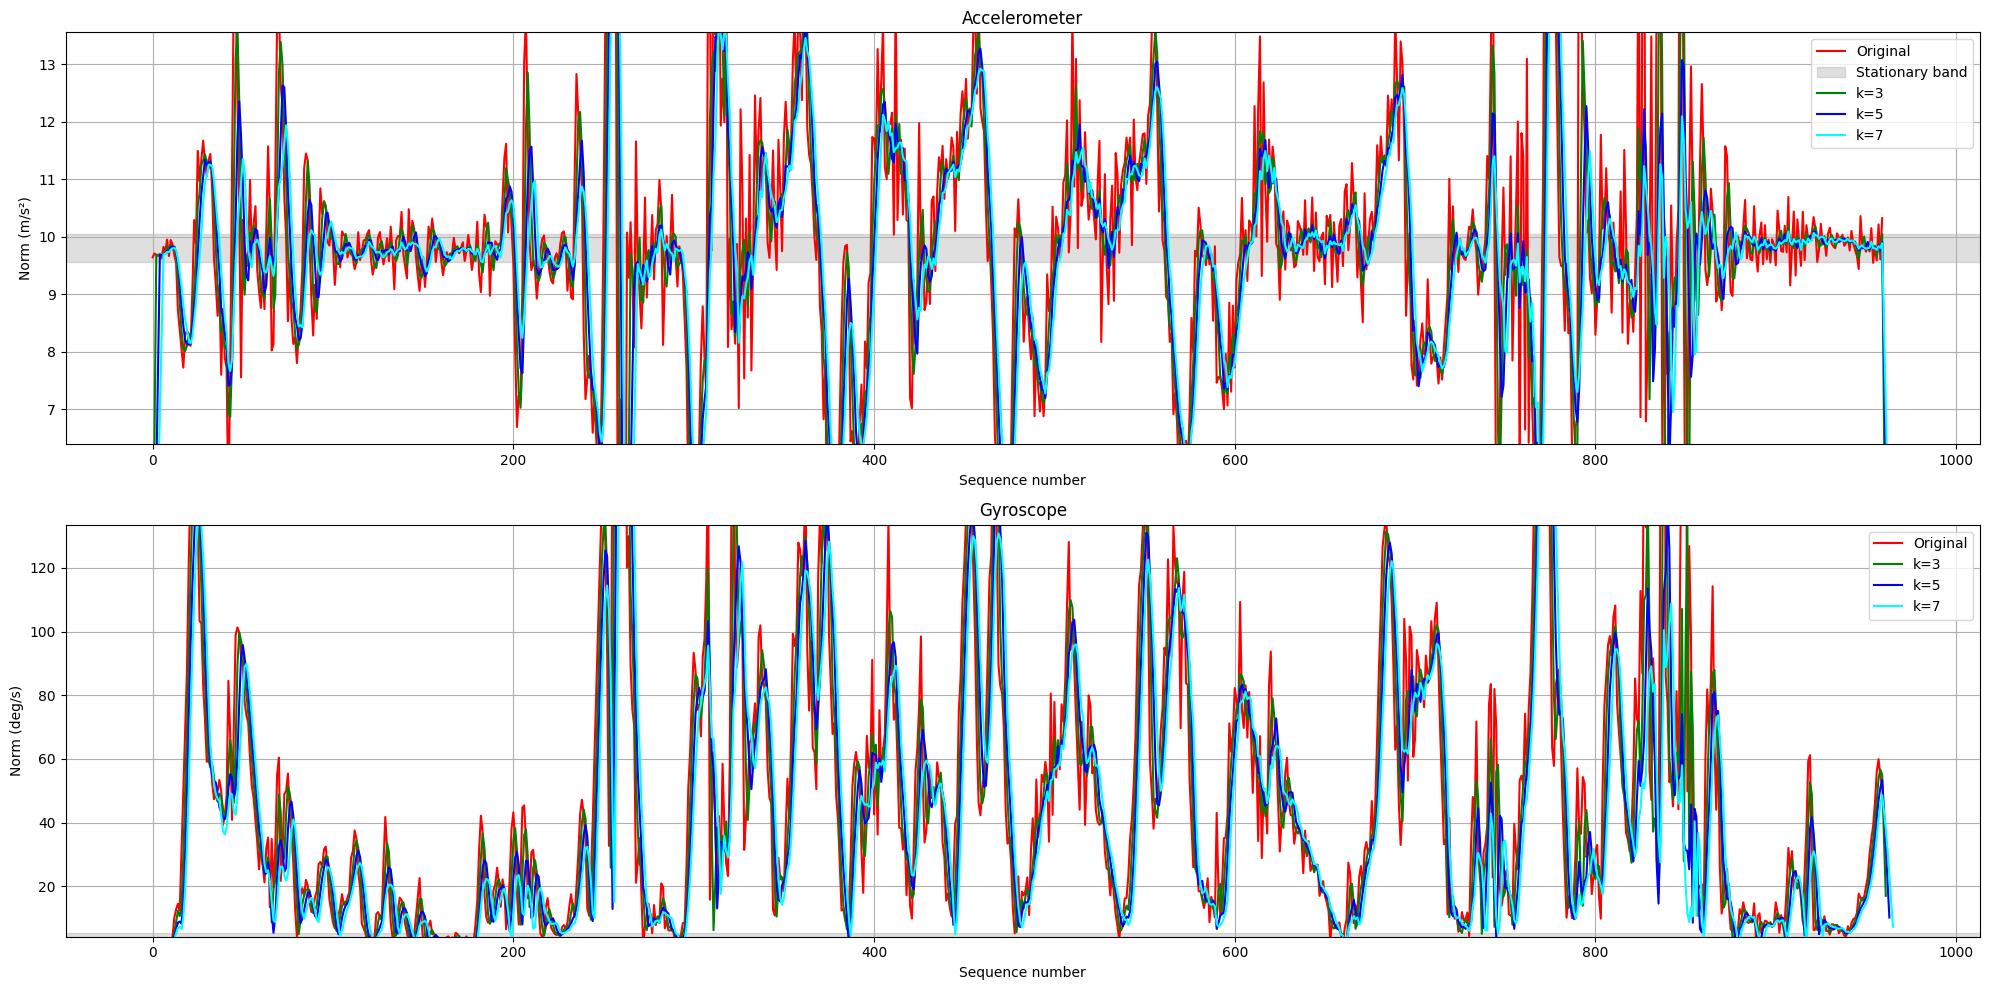

In [160]:
# CHOSEN_CAPTURE = sixFaceStationaryCaptures[0]
# CHOSEN_CAPTURE = tiltedStationaryCaptures[0]
# CHOSEN_CAPTURE = simpleRotationsCaptures[0]
CHOSEN_CAPTURE = realExerciseCaptures[6]
smallKernels = [3, 5, 7]
plotFilteredSignal(CHOSEN_CAPTURE, 5, 95, smallKernels)

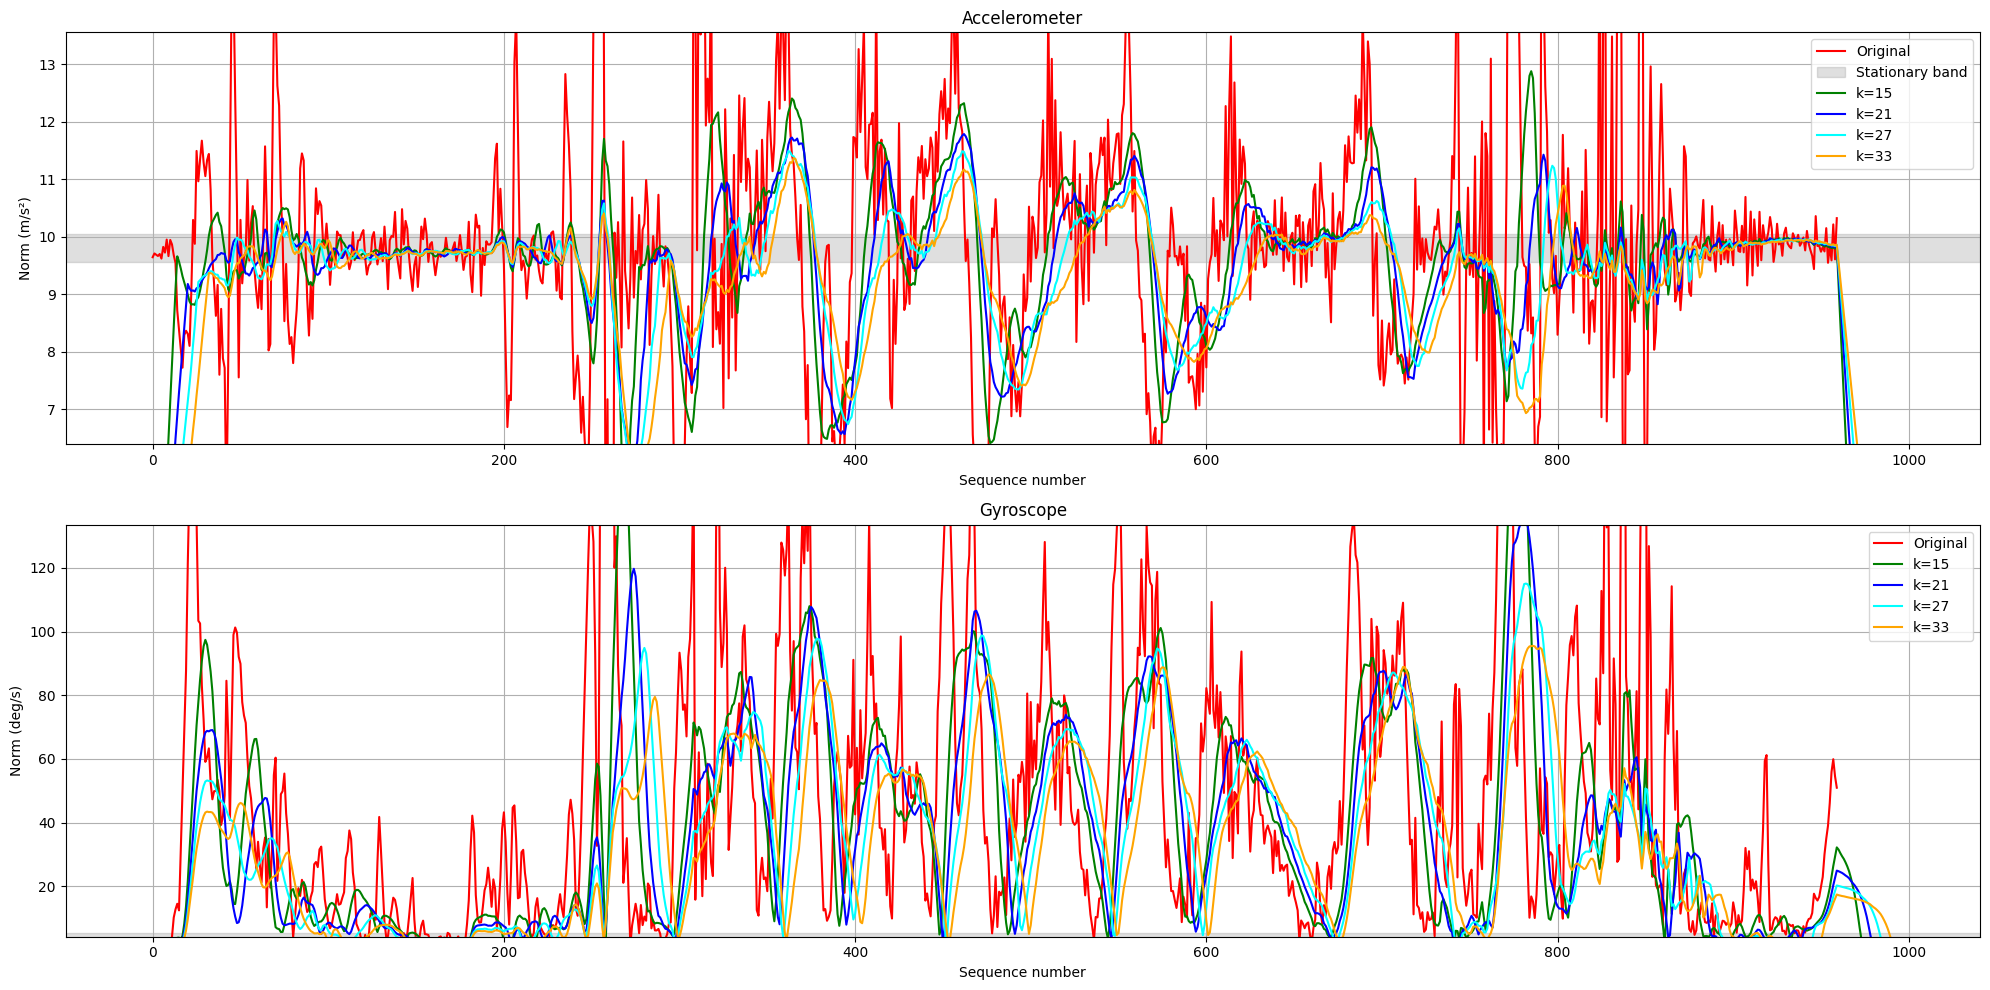

In [161]:
bigKernels = [15, 21, 27, 33]
plotFilteredSignal(CHOSEN_CAPTURE, 5, 95, bigKernels)

## Numerical inspection

The standard deviation of stationary intervals is a simple (but not perfect) proxy for noise. A relatively low value is preferred.

As pointed out earlier, performance gains are modest in general but more so with bigger kernels.

In [162]:
def computeFilteredSummaryMetrics(captures):
    print(f"Summary metrics for stationary captures before and after filtering:")

    aRawNorms = []
    wRawNorms = []
    memo = {}
    for capture in captures:
        memo[capture] = reader.readRaw(capture)
        _, a, w = memo[capture]
        stationaryFlags = stationaryChecker.areStationarySamples(a, w)
        aNorm = np.linalg.norm(a[stationaryFlags], axis=1)
        wNorm = np.linalg.norm(w[stationaryFlags], axis=1)
        aRawNorms.append(aNorm)
        wRawNorms.append(wNorm)
    aRawNorms = np.concatenate(aRawNorms)
    wRawNorms = np.concatenate(wRawNorms)

    aRawMean = np.mean(aRawNorms)
    aRawStd = np.std(aRawNorms)
    wRawMean = np.mean(wRawNorms)
    wRawStd = np.std(wRawNorms)
    print(
        f"k = 0 (raw):"
        f"\n\tAccel: mean={aRawMean:.6f} std={aRawStd:.6f}"
        f"\n\tGyro: mean={wRawMean:.6f} std={wRawStd:.6f}"
    )

    for kLen in [*smallKernels, *bigKernels]:
        aFilteredNorms = []
        wFilteredNorms = []
        for capture in captures:
            _, a, w = memo[capture]
            # Slicing is used to remove the edge effects of convolution with the incomplete kernel
            aFiltered = filterMovingAverage(a, kLen)[kLen:-kLen]
            wFiltered = filterMovingAverage(w, kLen)[kLen:-kLen]
            stationaryFlags = stationaryChecker.areStationarySamples(
                aFiltered, wFiltered
            )
            aNorm = np.linalg.norm(aFiltered[stationaryFlags], axis=1)
            wNorm = np.linalg.norm(wFiltered[stationaryFlags], axis=1)
            aFilteredNorms.append(aNorm)
            wFilteredNorms.append(wNorm)
        aFilteredNorms = np.concatenate(aFilteredNorms)
        wFilteredNorms = np.concatenate(wFilteredNorms)

        print(
            f"k={kLen}:"
            f"\n\tAccel: \tmeanDiff={aRawMean - np.mean(aFilteredNorms):.6f} \tstdDiff={aRawStd - np.std(aFilteredNorms):.6f}"
            f"\n\tGyro: \tmeanDiff={wRawMean - np.mean(wFilteredNorms):.6f} \tstdDiff={wRawStd - np.std(wFilteredNorms):.6f}"
        )

### Stationary captures

In [163]:
computeFilteredSummaryMetrics([*sixFaceStationaryCaptures, *tiltedStationaryCaptures])

Summary metrics for stationary captures before and after filtering:
k = 0 (raw):
	Accel: mean=9.803766 std=0.079637
	Gyro: mean=0.102710 std=0.274605
k=3:
	Accel: 	meanDiff=0.000195 	stdDiff=0.000745
	Gyro: 	meanDiff=0.026598 	stdDiff=0.020051
k=5:
	Accel: 	meanDiff=0.000211 	stdDiff=0.000993
	Gyro: 	meanDiff=0.038661 	stdDiff=0.060233
k=7:
	Accel: 	meanDiff=0.000215 	stdDiff=0.001105
	Gyro: 	meanDiff=0.047310 	stdDiff=0.100958
k=15:
	Accel: 	meanDiff=0.000217 	stdDiff=0.001220
	Gyro: 	meanDiff=0.060746 	stdDiff=0.094727
k=21:
	Accel: 	meanDiff=0.000058 	stdDiff=0.001251
	Gyro: 	meanDiff=0.057810 	stdDiff=0.033346
k=27:
	Accel: 	meanDiff=-0.000013 	stdDiff=0.001259
	Gyro: 	meanDiff=0.059775 	stdDiff=0.034543
k=33:
	Accel: 	meanDiff=-0.000029 	stdDiff=0.001257
	Gyro: 	meanDiff=0.065228 	stdDiff=0.076065


### Simple rotations captures

In [164]:
computeFilteredSummaryMetrics(simpleRotationsCaptures)

Summary metrics for stationary captures before and after filtering:
k = 0 (raw):
	Accel: mean=9.905658 std=0.066082
	Gyro: mean=1.294100 std=1.202752
k=3:
	Accel: 	meanDiff=-0.003731 	stdDiff=0.010299
	Gyro: 	meanDiff=0.125357 	stdDiff=0.023998
k=5:
	Accel: 	meanDiff=-0.004713 	stdDiff=0.015117
	Gyro: 	meanDiff=0.170168 	stdDiff=0.015215
k=7:
	Accel: 	meanDiff=-0.005191 	stdDiff=0.017343
	Gyro: 	meanDiff=0.218776 	stdDiff=0.041182
k=15:
	Accel: 	meanDiff=-0.005069 	stdDiff=0.018830
	Gyro: 	meanDiff=0.308194 	stdDiff=0.046767
k=21:
	Accel: 	meanDiff=-0.005035 	stdDiff=0.019470
	Gyro: 	meanDiff=0.373925 	stdDiff=0.094758
k=27:
	Accel: 	meanDiff=-0.004842 	stdDiff=0.019730
	Gyro: 	meanDiff=0.405464 	stdDiff=0.099088
k=33:
	Accel: 	meanDiff=-0.004401 	stdDiff=0.019684
	Gyro: 	meanDiff=0.404660 	stdDiff=0.071755


### Real exercise captures

In [165]:
computeFilteredSummaryMetrics(realExerciseCaptures)

Summary metrics for stationary captures before and after filtering:
k = 0 (raw):
	Accel: mean=9.852055 std=0.124279
	Gyro: mean=3.201039 std=1.285256
k=3:
	Accel: 	meanDiff=-0.004944 	stdDiff=0.010997
	Gyro: 	meanDiff=0.040448 	stdDiff=0.025711
k=5:
	Accel: 	meanDiff=-0.008740 	stdDiff=0.020230
	Gyro: 	meanDiff=0.080912 	stdDiff=0.027244
k=7:
	Accel: 	meanDiff=-0.000808 	stdDiff=0.020016
	Gyro: 	meanDiff=-0.026110 	stdDiff=0.027640
k=15:
	Accel: 	meanDiff=0.000948 	stdDiff=0.026392
	Gyro: 	meanDiff=-0.018979 	stdDiff=0.059305
k=21:
	Accel: 	meanDiff=0.001805 	stdDiff=0.036414
	Gyro: 	meanDiff=-0.045969 	stdDiff=0.042908
k=27:
	Accel: 	meanDiff=0.011667 	stdDiff=0.035225
	Gyro: 	meanDiff=0.069711 	stdDiff=0.068885
k=33:
	Accel: 	meanDiff=0.019412 	stdDiff=0.034447
	Gyro: 	meanDiff=0.007064 	stdDiff=0.057564


## Conclusion

A kernel of $k = 5$ paired with the built-in filter (not present in exported results) should provide a good degree of noise reduction without compromising too much the signal sharpness and responsiveness.

In [166]:
CHOSEN_KERNEL_LEN = 5


def exportResults(captures):
    for capture in captures:
        seq, a, w = reader.readRaw(capture)
        newSeq = np.concatenate(
            [
                seq,
                np.arange(int(seq[-1]) + 1, int(seq[-1]) + CHOSEN_KERNEL_LEN, 1),
            ]
        )
        aFiltered = filterMovingAverage(a, CHOSEN_KERNEL_LEN)
        wFiltered = filterMovingAverage(w, CHOSEN_KERNEL_LEN)

        oldFileName = capture.split("/")[-1].split(".")[0]
        writer.writeRaw(
            f"./output/{oldFileName}-filt-box5.csv", newSeq, aFiltered, wFiltered
        )


exportResults([*sixFaceStationaryCaptures, *tiltedStationaryCaptures])
exportResults(simpleRotationsCaptures)
exportResults(realExerciseCaptures)